<h1 style="
font-family:Arial;
font-size:40px;
font-weight:bold;
color:#222;
text-align:center;
margin-bottom:20px;
">
Product Price Trend Analysis
</h1>

<h2 style="
font-family:Calibri;
font-size:28px;
color:#333;
border-bottom:2px solid #ccc;
padding-bottom:5px;
">
Objective
</h2>

<p style="
font-family:Arial;
font-size:17px;
line-height:1.6;
color:#444;
">
Analyze long-term product pricing behavior and identify trends, volatility patterns, and staged pricing changes over time.
</p>

<h2 style="
font-family:Arial;
font-size:28px;
color:#333;
border-bottom:2px solid #ccc;
padding-bottom:6px;
">
Dataset Overview
</h2>

<p style="
font-family:Calibri;
font-size:18px;
line-height:1.7;
color:#444;
">
The dataset contains historical product pricing information including product names, dates, and prices across multiple years.
</p>

<h2 style="
font-family:Arial;
font-size:28px;
color:#333;
border-bottom:2px solid #ccc;
padding-bottom:6px;
">
Data Cleaning
</h2>

<ul style="
font-family:Calibri;
font-size:18px;
line-height:1.9;
color:#444;
">
<li>Removed duplicate records</li>
<li>Handled missing values</li>
<li>Converted date columns into datetime format</li>
<li>Prepared data for visualization</li>
</ul>

<h2 style="
font-family:Arial;
font-size:28px;
color:#333;
border-bottom:2px solid #ccc;
padding-bottom:6px;
">
Exploratory Data Analysis
</h2>

<p style="
font-family:Calibri;
font-size:18px;
line-height:1.7;
color:#444;
">
Exploratory analysis was performed to examine long-term pricing consistency and product growth trends.
</p>

<h2 style="
font-family:Arial;
font-size:28px;
color:#333;
border-bottom:2px solid #ccc;
padding-bottom:6px;
">
Visualization
</h2>

<p style="
font-family:Calibri;
font-size:18px;
line-height:1.7;
color:#444;
">
The graph below illustrates long-term product pricing behavior across time periods.
</p>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import random
from faker import Faker

In [14]:
fake = Faker()
df = pd.read_csv("messy_sales_data.csv")

In [15]:
df["Price"] = pd.to_numeric(df["Price"],errors = 'coerce')

In [16]:


df["Price"] = np.nan
#df["Price"]


def standardize_dates(d):
    match = re.search(r"(\d{4})-(\d{1,2})-(\d{1,2})",d)
    if match:
        return f"{match.group(1)}-{match.group(2).zfill(2)}-{match.group(3).zfill(2)}"
    return np.nan
dates = [standardize_dates(d) for d in df["Date"]]
df["Date"] = dates


datetime_obj = []
for i in range(2000,2015):
    for j in range(1,13):
        for k in range(1,28):
            if j < 10 and k < 10:
                datetime_obj.append(f"{i}-0{j}-0{k}")
            
            elif j < 10 and k >= 10:
                datetime_obj.append(f"{i}-0{j}-{k}")
            elif j >= 10 and k < 10:
                datetime_obj.append(f"{i}-{j}-0{k}")
            else:
                datetime_obj.append(f"{i}-{j}-{k}")


df.loc[df["Date"].isna() , "Date"] = np.random.choice(datetime_obj , df["Date"].isna().sum())

In [17]:
df["Product"] = df["Product"].str.capitalize()


In [18]:
df.loc[df["Date"].isna() , "Product"] = np.nan
df.loc[df["Date"].isna() , "Price"] = np.nan
df["Date"] = pd.to_datetime(df["Date"])

In [19]:
mask1 = (df["Date"].dt.year >= df["Date"].dt.year.min()) & (df["Date"].dt.year <= 1980)
mask2 = (df["Date"].dt.year >= 1981) & (df["Date"].dt.year <= 1990)
mask3 = (df["Date"].dt.year >= 1991) & (df["Date"].dt.year <= 2000)
mask4 = (df["Date"].dt.year >= 2001) & (df["Date"].dt.year <= 2010)
mask5 = (df["Date"].dt.year >= 2010) & (df["Date"].dt.year <= 2020)
mask6 = (df["Date"].dt.year >= 2020) & (df["Date"].dt.year <= df["Date"].dt.year.max())

masks = ["",mask1 , mask2,mask3,mask4,mask5,mask6]
for j in range(1,7):
    df.loc[masks[j] & (df["Product"] == "Laptop"),"Price"] = 100 *j
    df.loc[masks[j] & (df["Product"] == "Phone"),"Price"] = 20 *j
    df.loc[masks[j] & (df["Product"] == "Keyboard"),"Price"] = 5 *j
    df.loc[masks[j] & (df["Product"] == "Monitor"),"Price"] = 10 *j
    df.loc[masks[j] & (df["Product"] == "Tablet"),"Price"] = 15 *j
    df.loc[masks[j] & (df["Product"] == "Headphones"),"Price"] = 7 *j
    

In [20]:
df.loc[df["Quantity"].isna(),"Quantity"] = np.random.randint(1,4,df["Quantity"].isna().sum())
df["Total Price"] = df["Price"] * df["Quantity"]


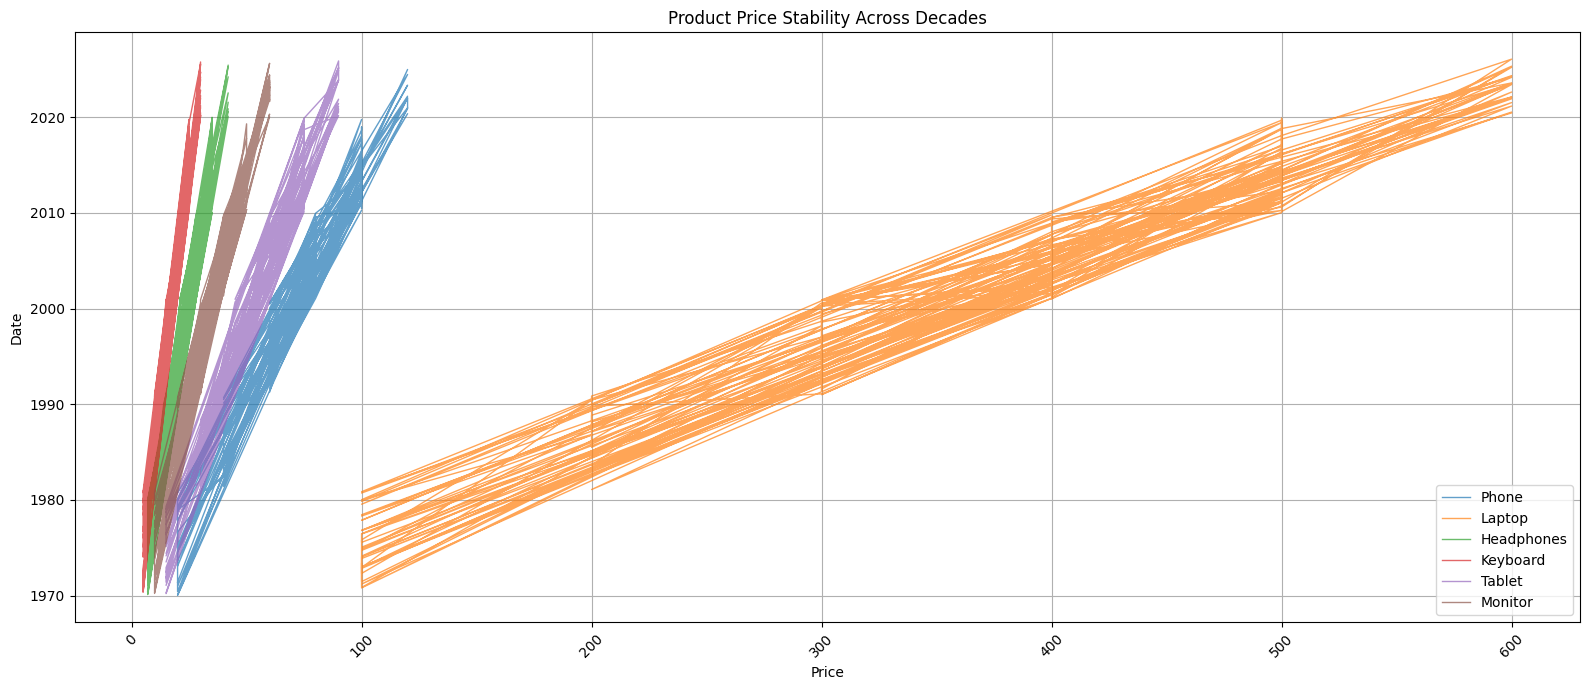

In [21]:
plt.figure(figsize=(16,7))

for product in df["Product"].unique():

    temp_df = df[df["Product"] == product].copy()
    
    plt.plot(
        temp_df["Price"],
        temp_df["Date"],
        label = product,
        alpha = 0.7,
        linewidth=1,
       
    )
    

plt.xlabel("Price")
plt.ylabel("Date")
plt.title("Product Price Stability Across Decades")
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.legend()



<h2 style="
font-family:Arial;
font-size:28px;
color:#333;
border-bottom:2px solid #ccc;
padding-bottom:6px;
">
Key Findings
</h2>

<ul style="
font-family:Calibri;
font-size:18px;
line-height:2;
color:#444;
">
<li>Prices remained stable for extended periods.</li>

<li>Products showed low short-term volatility.</li>

<li>Long-term price growth occurred gradually.</li>

<li>Several products exhibited step-like pricing behavior.</li>
</ul>

<h2 style="
font-family:Arial;
font-size:28px;
color:#333;
border-bottom:2px solid #ccc;
padding-bottom:6px;
">
Conclusion
</h2>

<p style="
font-family:Calibri;
font-size:18px;
line-height:1.8;
color:#444;
">
The analysis demonstrated stable long-term pricing patterns with gradual staged growth and limited short-term fluctuations.
</p>

In [22]:
name_list = [fake.name() for _ in range(5)]
df.loc[df["Name"].isna() ,"Name"] = np.random.choice(name_list , df["Name"].isna().sum())

df["Email"] = df["Name"].str.replace(" ","")  +"@example" + "." + np.random.choice(["com","org","net"] , len(df["Email"]))

df["Country"] = df["Country"].str.capitalize()
df["Country"] = df["Country"].replace( {"United kingdom" : "Uk" , "United states" : "Usa"})

In [23]:
df.to_csv("Cleaned_Csv_Data.csv")